# Iris Classification using Machine Learning

## Alfido Tech Machine Learning Internship — Task 01

### Project Overview

This project focuses on building a machine learning classification model to predict the species of an iris flower using its sepal and petal measurements.

The dataset contains four numerical features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The project includes exploratory data analysis, data visualization, model training, model comparison, and evaluation using multiple classification algorithms.

The following machine learning algorithms are implemented and compared:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree

The best-performing model is selected based on evaluation metrics and saved using Python's Pickle library for future predictions.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score
)

# Model saving
import pickle

# Display plots inside notebook
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import pandas as pd

df = pd.read_csv("C:\\Users\\manish gupta\\OneDrive\\Documents\\GitHub\\Alfido-Tech-ML-Internship\\Task-01-Iris-Classification\\data\\IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.shape

(150, 5)

In [5]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3)

In [9]:
df["species"].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

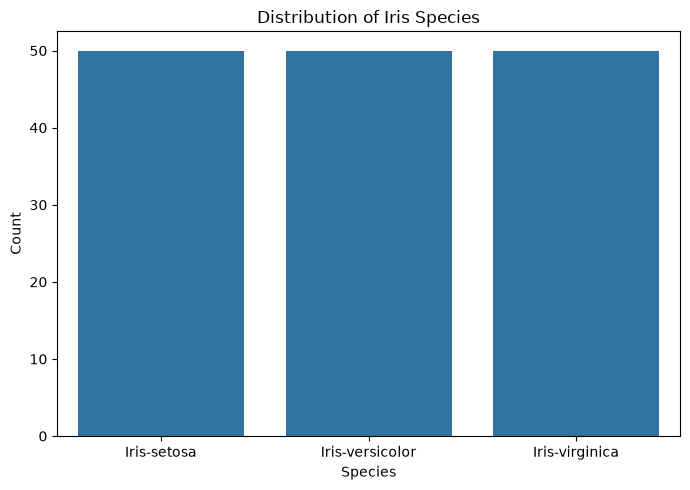

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(x=df.iloc[:, -1])

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../screenshots/class_distribution.png", dpi=300)
plt.show()

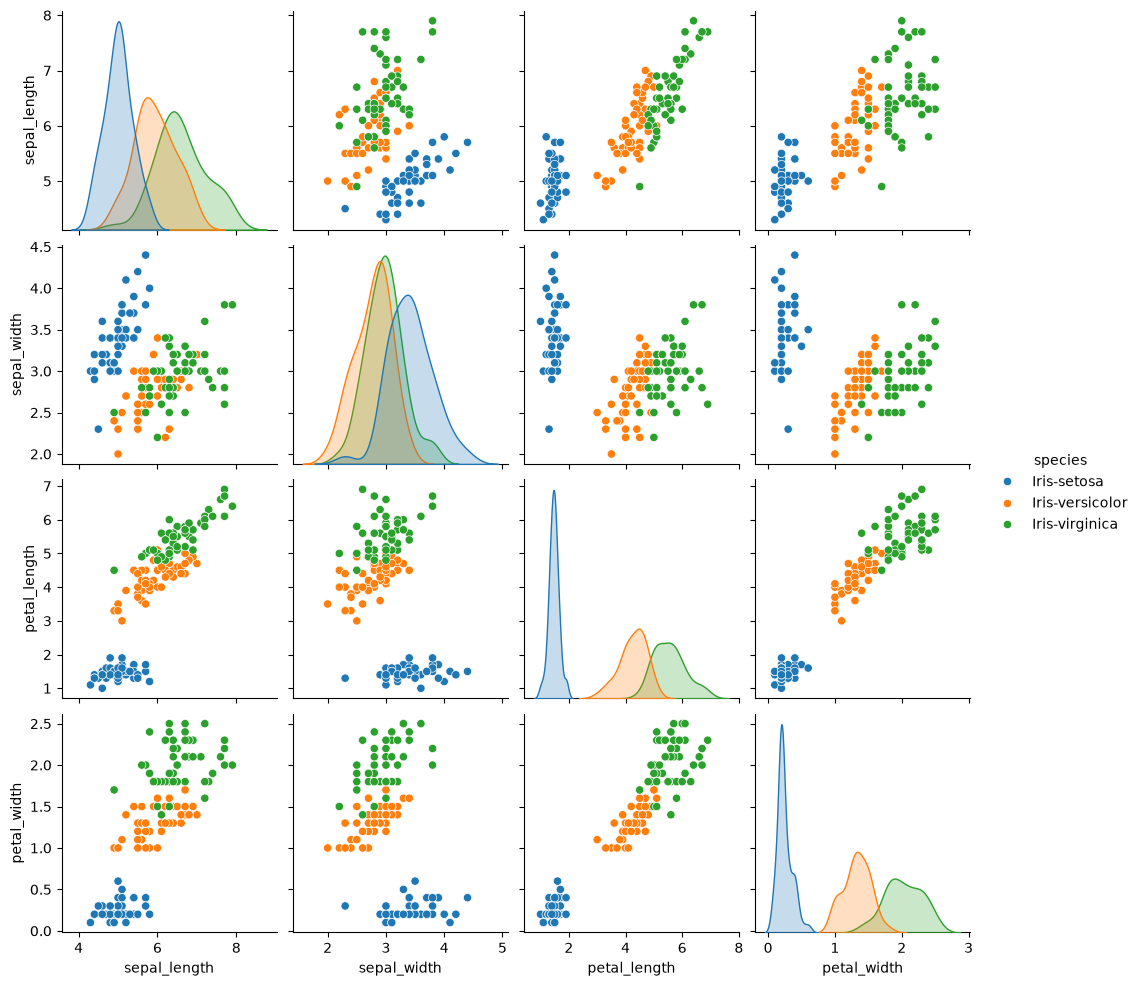

In [12]:
sns.pairplot(df, hue=df.columns[-1])

plt.savefig("../screenshots/pairplot.png", dpi=300)
plt.show()

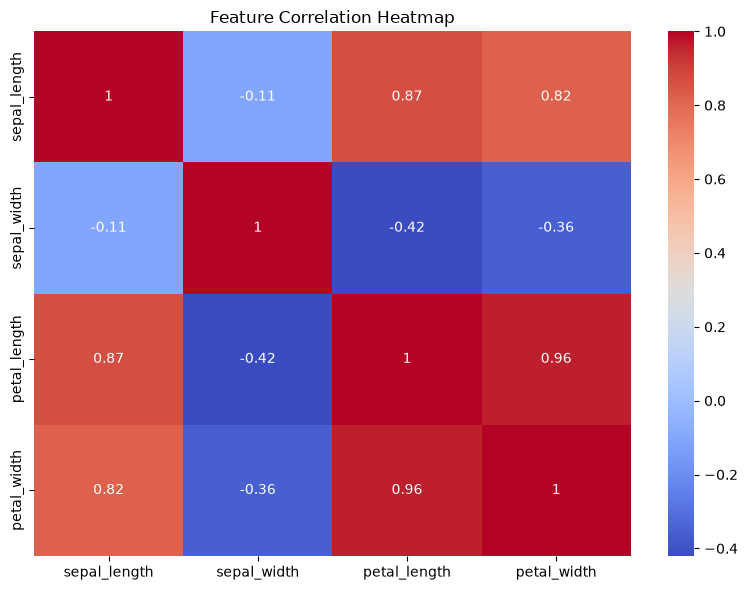

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.savefig("../screenshots/correlation_heatmap.png", dpi=300)
plt.show()

In [14]:
X = df.iloc[:, :4]
y = df.iloc[:, -1]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [17]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [18]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN trained successfully.")

KNN trained successfully.


In [19]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [20]:
# Predictions from all three models

logistic_pred = logistic_model.predict(X_test_scaled)
knn_pred = knn_model.predict(X_test_scaled)
tree_pred = tree_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [21]:
logistic_accuracy = accuracy_score(y_test, logistic_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("KNN Accuracy:", knn_accuracy)
print("Decision Tree Accuracy:", tree_accuracy)

Logistic Regression Accuracy: 0.9333333333333333
KNN Accuracy: 0.9333333333333333
Decision Tree Accuracy: 0.9333333333333333


In [22]:
print("Logistic Regression")
print("Precision:", precision_score(y_test, logistic_pred, average="weighted"))
print("Recall:", recall_score(y_test, logistic_pred, average="weighted"))

print("\nKNN")
print("Precision:", precision_score(y_test, knn_pred, average="weighted"))
print("Recall:", recall_score(y_test, knn_pred, average="weighted"))

print("\nDecision Tree")
print("Precision:", precision_score(y_test, tree_pred, average="weighted"))
print("Recall:", recall_score(y_test, tree_pred, average="weighted"))

Logistic Regression
Precision: 0.9333333333333333
Recall: 0.9333333333333333

KNN
Precision: 0.9444444444444445
Recall: 0.9333333333333333

Decision Tree
Precision: 0.9333333333333333
Recall: 0.9333333333333333


In [23]:
print("Logistic Regression")
print(classification_report(y_test, logistic_pred))

print("\nKNN")
print(classification_report(y_test, knn_pred))

print("\nDecision Tree")
print(classification_report(y_test, tree_pred))

Logistic Regression
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


KNN
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


Decision Tree
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90     

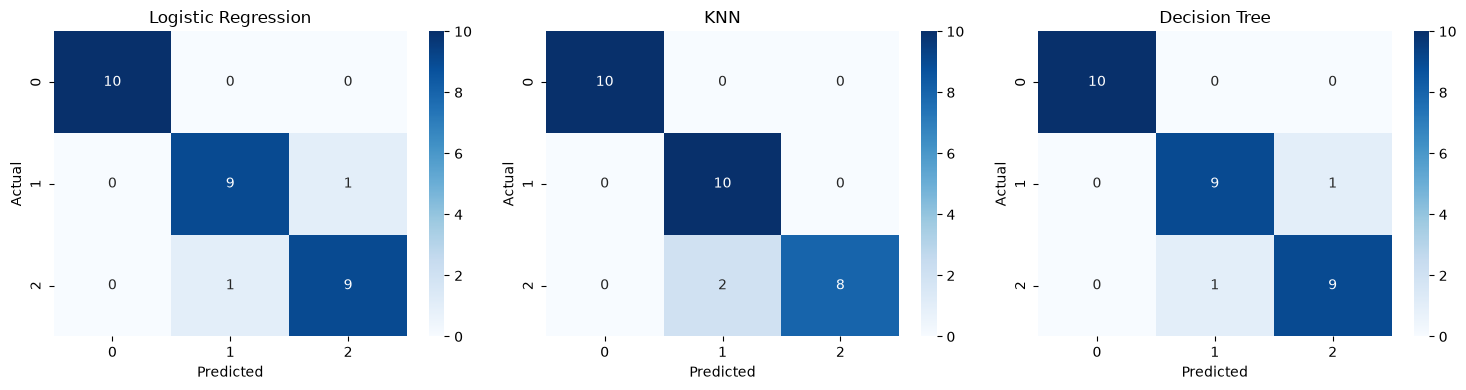

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", logistic_pred),
    ("KNN", knn_pred),
    ("Decision Tree", tree_pred)
]

for ax, (name, prediction) in zip(axes, models):
    cm = confusion_matrix(y_test, prediction)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../screenshots/confusion_matrices.png", dpi=300)
plt.show()

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        tree_accuracy
    ],
    "Precision": [
        precision_score(y_test, logistic_pred, average="weighted"),
        precision_score(y_test, knn_pred, average="weighted"),
        precision_score(y_test, tree_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, logistic_pred, average="weighted"),
        recall_score(y_test, knn_pred, average="weighted"),
        recall_score(y_test, tree_pred, average="weighted")
    ]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.933333,0.933333,0.933333
1,KNN,0.933333,0.944444,0.933333
2,Decision Tree,0.933333,0.933333,0.933333


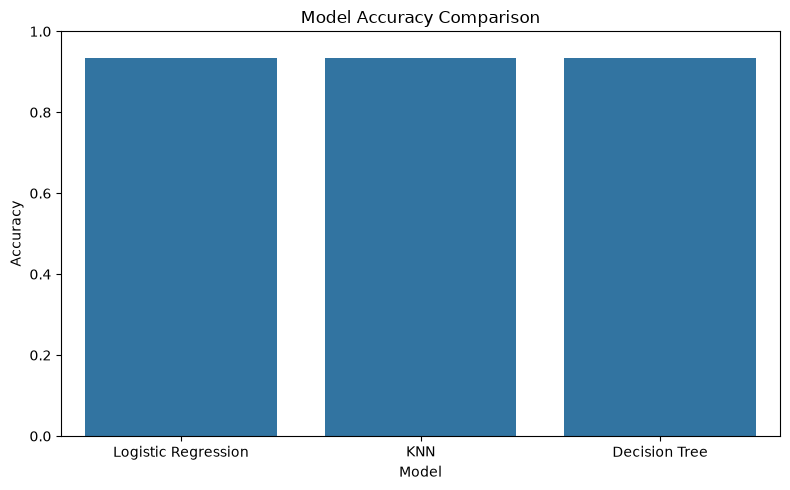

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("../screenshots/model_comparison.png", dpi=300)
plt.show()

In [27]:
best_model_name = results.loc[results["Accuracy"].idxmax(), "Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [28]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model
elif best_model_name == "KNN":
    best_model = knn_model
else:
    best_model = tree_model

print("Selected Best Model:", best_model_name)

Selected Best Model: Logistic Regression


In [29]:
with open("../model/iris_best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best model saved successfully!")

Best model saved successfully!


In [30]:
with open("../model/iris_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


In [31]:
with open("../model/iris_best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [32]:
if best_model_name in ["Logistic Regression", "KNN"]:
    test_prediction = loaded_model.predict(X_test_scaled)
else:
    test_prediction = loaded_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, test_prediction))

Test Accuracy: 0.9333333333333333


In [33]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

if best_model_name in ["Logistic Regression", "KNN"]:
    new_flower_scaled = scaler.transform(new_flower)
    prediction = loaded_model.predict(new_flower_scaled)
else:
    prediction = loaded_model.predict(new_flower)

print("Predicted Iris Species:", prediction[0])

Predicted Iris Species: Iris-setosa


c:\Users\manish gupta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
print("New Flower Measurements")
print("Sepal Length: 5.1 cm")
print("Sepal Width: 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width: 0.2 cm")

print("\nPredicted Species:", prediction[0])

New Flower Measurements
Sepal Length: 5.1 cm
Sepal Width: 3.5 cm
Petal Length: 1.4 cm
Petal Width: 0.2 cm

Predicted Species: Iris-setosa


In [35]:
best_result = results[results["Model"] == best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:", round(best_result["Accuracy"].iloc[0] * 100, 2), "%")
print("Precision:", round(best_result["Precision"].iloc[0] * 100, 2), "%")
print("Recall:", round(best_result["Recall"].iloc[0] * 100, 2), "%")

Best Model: Logistic Regression
Accuracy: 93.33 %
Precision: 93.33 %
Recall: 93.33 %


## Conclusion

In this project, three supervised machine learning algorithms — Logistic Regression, K-Nearest Neighbors (KNN), and Decision Tree — were trained to classify iris flower species based on sepal and petal measurements.

Exploratory Data Analysis showed clear differences between the iris species, particularly in petal measurements. The models were evaluated using accuracy, precision, recall, classification reports, and confusion matrices.

The model with the highest accuracy was selected as the best model and saved using Python Pickle. An example inference was also performed using a new flower's measurements to demonstrate how the saved model can be used for future predictions.

In [37]:
results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.933333,0.933333,0.933333
1,KNN,0.933333,0.944444,0.933333
2,Decision Tree,0.933333,0.933333,0.933333


## Project Summary

### Dataset
Iris flower classification dataset containing sepal and petal measurements.

### Features
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### Algorithms
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- Confusion Matrix

### Model Saving
The best-performing model was saved using Python Pickle.

### Inference
A new iris flower can be classified by providing its four measurements to the saved model.